Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns
import matplotlib.pyplot as plt

Load Dataset

In [5]:
import pandas as pd

In [15]:
from google.colab import files
uploaded = files.upload()

Saving ai4i2020.csv to ai4i2020.csv


In [16]:
import pandas as pd

df = pd.read_csv("ai4i2020.csv")

print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

Data Preprocessing

In [17]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [18]:
df = df.drop(["UDI","Product ID"], axis=1)

In [19]:
df["Type"] = df["Type"].map({"L":0,"M":1,"H":2})

Feature and Target

In [20]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

Train Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Random Forest Model

In [22]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.999


In [26]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

GridSearchCV

In [29]:
from sklearn.model_selection import GridSearchCV

In [30]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(rf, param_grid, cv=3)

grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, None],
                         'n_estimators': [100, 200]})

In [31]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

Best Model

In [32]:
best_model = grid.best_estimator_

print("Best Model:", best_model)

Best Model: RandomForestClassifier(max_depth=5, random_state=42)


Predictions

In [33]:
y_pred = best_model.predict(X_test)

Metrics

In [34]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



Confusion Matrix

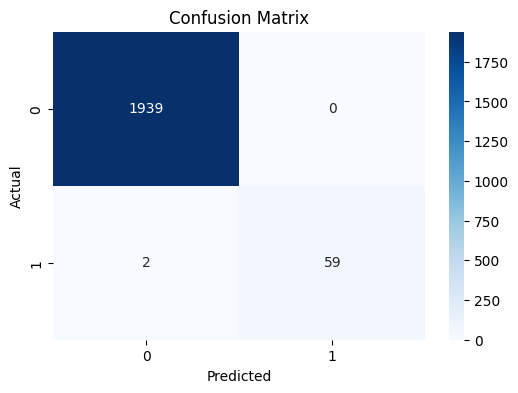

In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

ROC Curve

In [37]:
from sklearn.metrics import roc_curve, auc

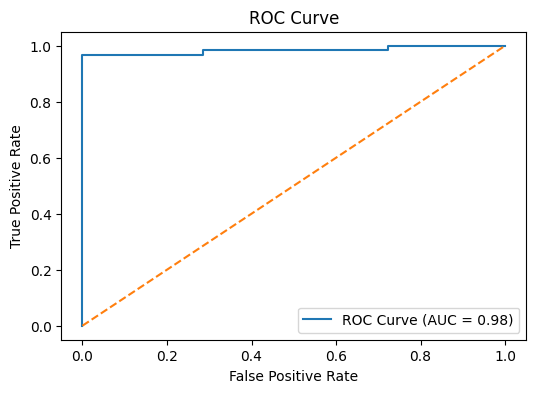

In [38]:
y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

Feature Importance

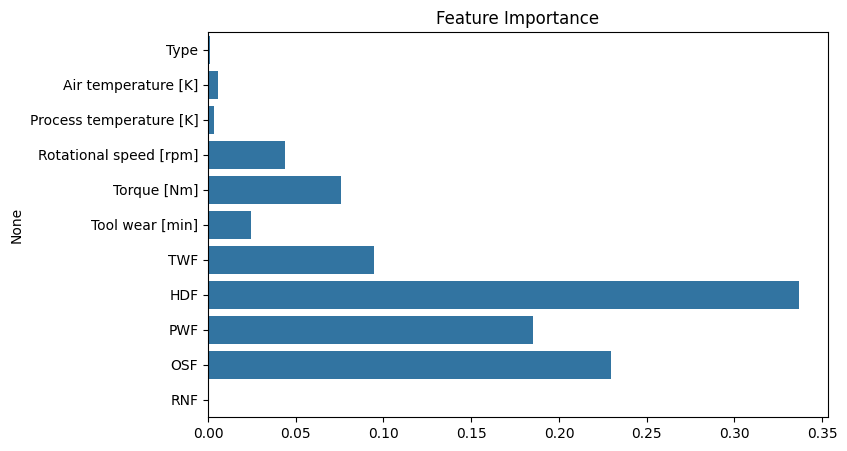

In [39]:
importances = best_model.feature_importances_

feature_names = X.columns

plt.figure(figsize=(8,5))

sns.barplot(x=importances, y=feature_names)

plt.title("Feature Importance")

plt.show()

In [41]:
!pip install shap

SHAP Interpretability

In [43]:
import shap

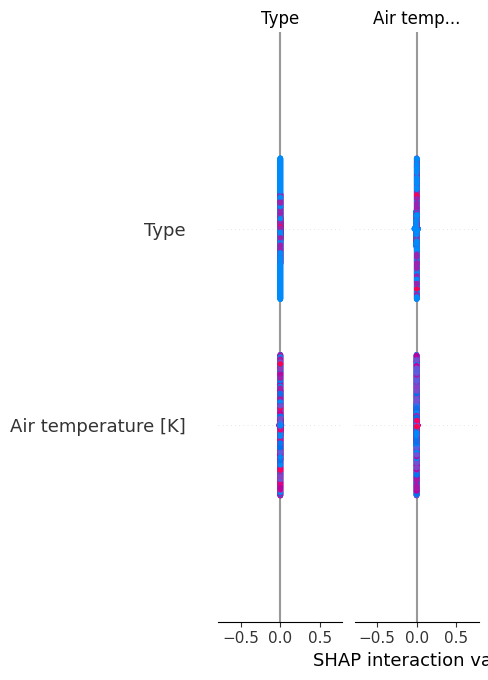

In [44]:
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

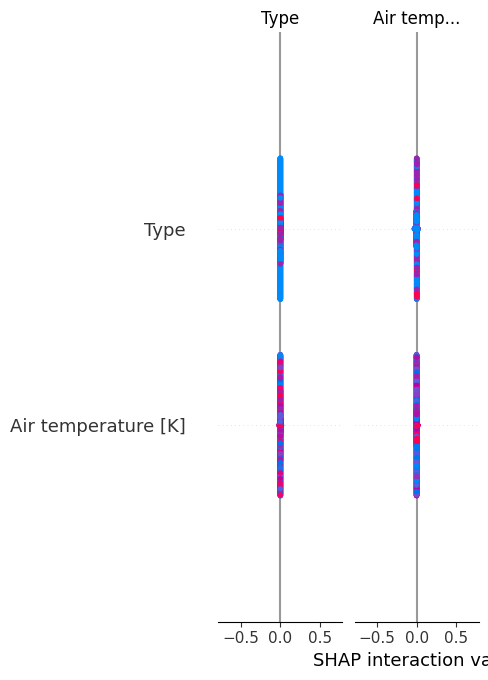

In [45]:
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)